In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\project\data\processed\clean_data.csv")
print(df.shape)

(999999, 38)


In [3]:
df['churn'].value_counts(normalize=True) * 100

churn
0    90.07729
1     9.92271
Name: proportion, dtype: float64

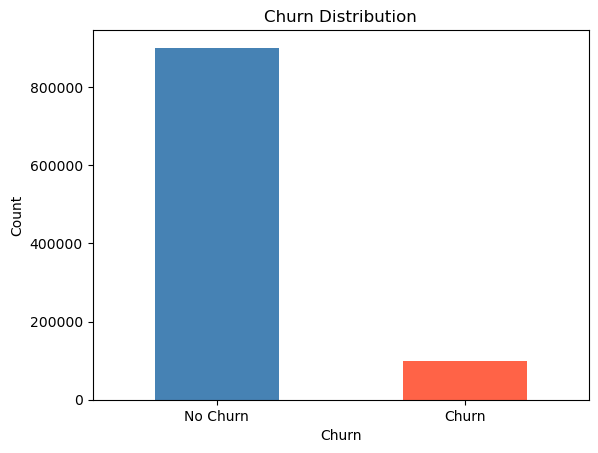

In [4]:
df['churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)
plt.show()

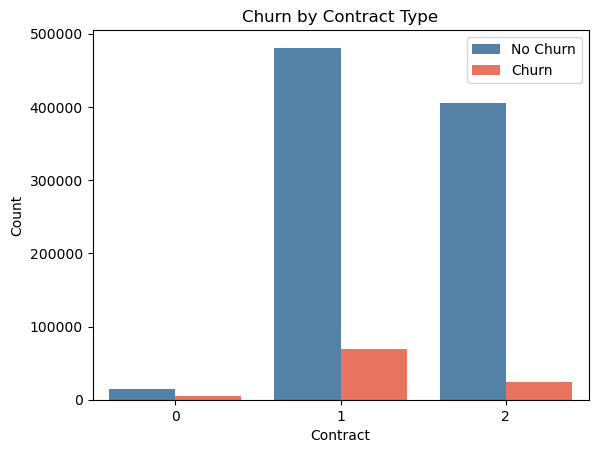

In [5]:
sns.countplot(data=df, x='contract', hue='churn', palette=['steelblue', 'tomato'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.legend(['No Churn', 'Churn'])
plt.show()

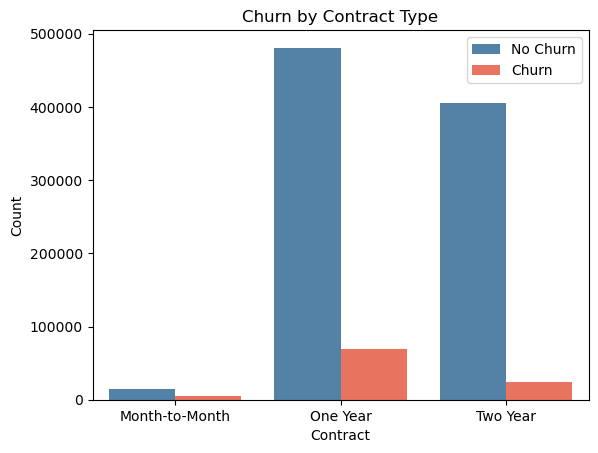

In [6]:
contract_map = {0: 'Month-to-Month', 1: 'One Year', 2: 'Two Year'}
df['contract_label'] = df['contract'].map(contract_map)

sns.countplot(data=df, x='contract_label', hue='churn', palette=['steelblue', 'tomato'],
              order=['Month-to-Month', 'One Year', 'Two Year'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.legend(['No Churn', 'Churn'])
plt.show()

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_30088\2971212348.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='customer_satisfaction', palette=['steelblue', 'tomato'])


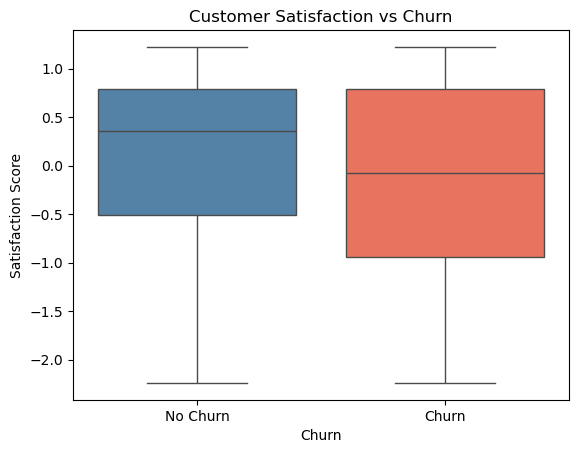

In [7]:
sns.boxplot(data=df, x='churn', y='customer_satisfaction', palette=['steelblue', 'tomato'])
plt.title('Customer Satisfaction vs Churn')
plt.xlabel('Churn')
plt.ylabel('Satisfaction Score')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

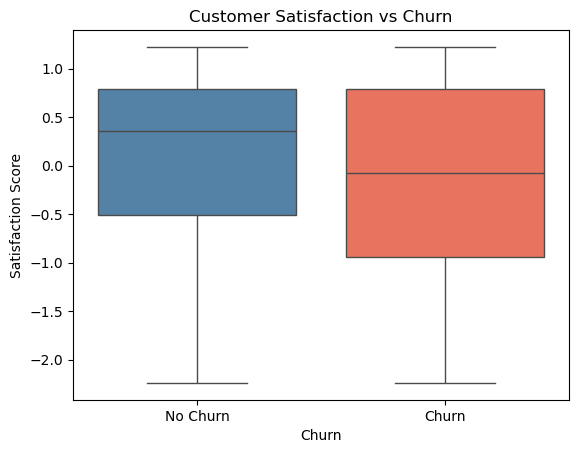

In [9]:
sns.boxplot(data=df, x='churn', y='customer_satisfaction', 
            hue='churn', palette=['steelblue', 'tomato'], legend=False)
plt.title('Customer Satisfaction vs Churn')
plt.xlabel('Churn')
plt.ylabel('Satisfaction Score')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

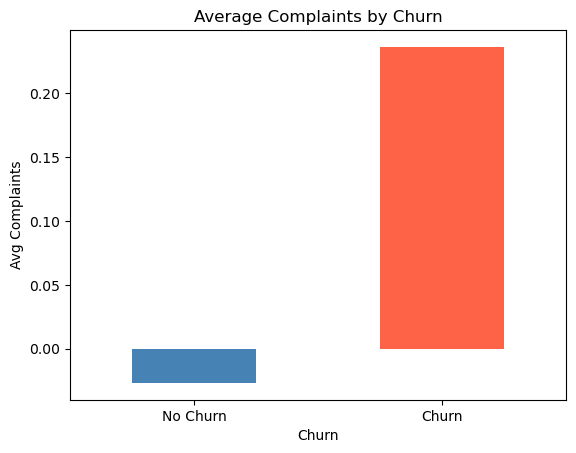

In [11]:
df.groupby('churn')['num_complaints'].mean().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Average Complaints by Churn')
plt.xlabel('Churn')
plt.ylabel('Avg Complaints')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)
plt.show()

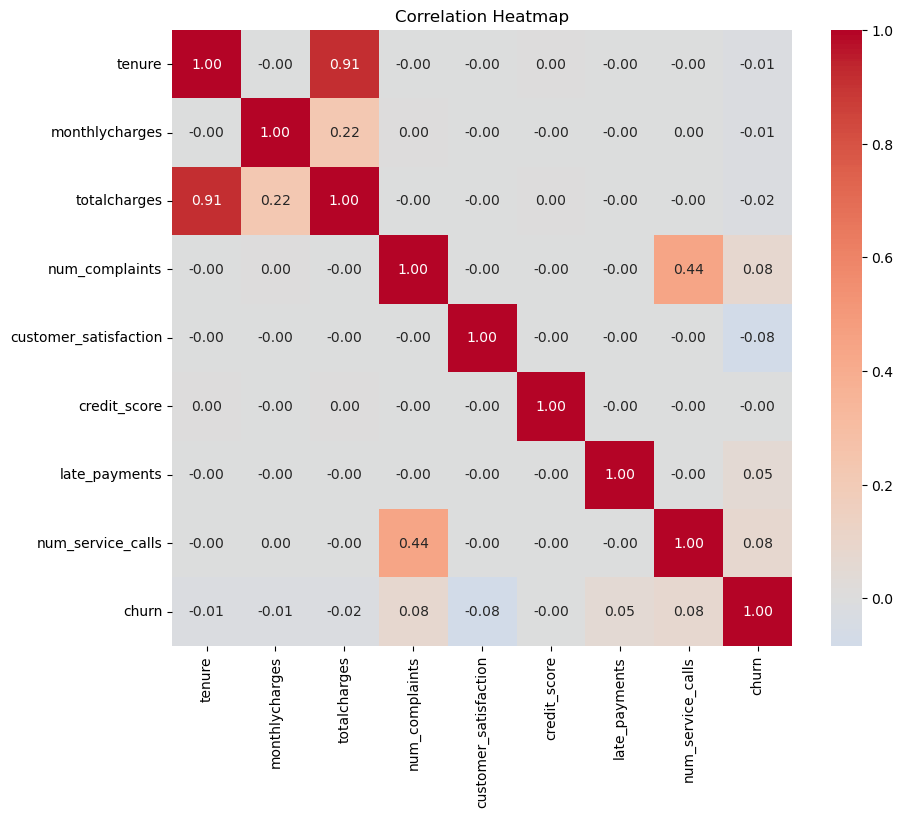

In [12]:
num_cols = ['tenure', 'monthlycharges', 'totalcharges', 
            'num_complaints', 'customer_satisfaction',
            'credit_score', 'late_payments', 'num_service_calls', 'churn']

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
import joblib

scaler = joblib.load(r"D:\project\models\scaler\scaler.pk1")
tenure_original = scaler.inverse_transform(df[['tenure'] + [c for c in df.columns if c in ['age', 'annual_income', 'tenure', 'monthlycharges', 'totalcharges', 'avg_monthly_gb', 'credit_score', 'num_service_calls', 'num_complaints', 'customer_satisfaction', 'days_since_last_interaction', 'late_payments', 'num_services']]])

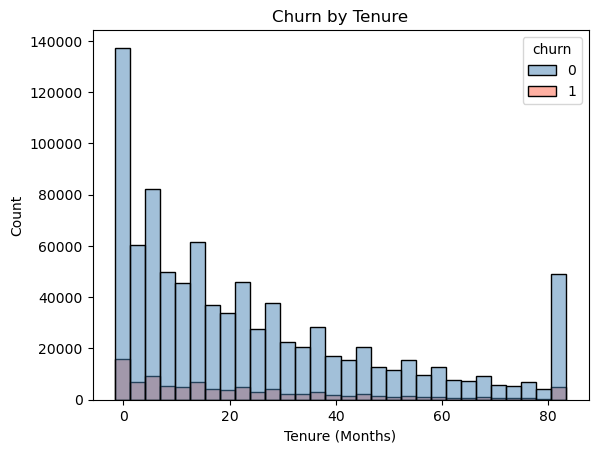

In [18]:
df_viz = df.copy()
df_viz['tenure_orig'] = df_viz['tenure'] * 24 + 24

sns.histplot(data=df_viz, x='tenure_orig', hue='churn',
             palette=['steelblue', 'tomato'], bins=30)
plt.title('Churn by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

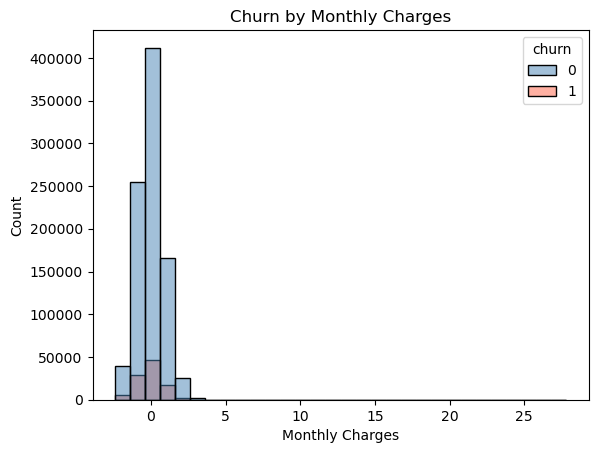

In [19]:
sns.histplot(data=df_viz, x='monthlycharges', hue='churn',
             palette=['steelblue', 'tomato'], bins=30)
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_30088\4293058197.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_viz.groupby('charges_bucket')['churn'].mean().plot(kind='bar', color='tomato')


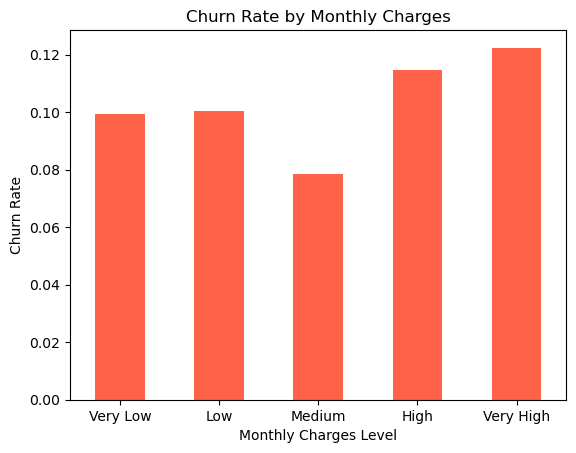

In [20]:
df_viz['charges_bucket'] = pd.cut(df_viz['monthlycharges'], 
                                   bins=5, 
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

df_viz.groupby('charges_bucket')['churn'].mean().plot(kind='bar', color='tomato')
plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charges Level')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()